In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12_sft-full"

data_dir = Path("data") / "ch12" / "sft-full"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
58,2400,53,train,4.327,0.0001,2025-10-01T12:53:55%:z
57,2350,52,train,4.338,0.0001,2025-10-01T12:51:09%:z
56,2300,51,train,4.366,0.0001,2025-10-01T12:48:23%:z
53,2200,48,train,4.417,0.0001,2025-10-01T11:37:40%:z
52,2150,47,train,4.448,0.0001,2025-10-01T11:34:54%:z
51,2100,46,train,4.463,0.0001,2025-10-01T11:32:07%:z
55,2250,49,train,4.468,0.0001,2025-10-01T12:45:38%:z
48,2000,44,train,4.486,0.0001,2025-09-30T20:52:12%:z
47,1950,43,train,4.510,0.0001,2025-09-30T20:49:28%:z
46,1900,42,train,4.536,0.0001,2025-09-30T20:46:43%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
47,1950,43,train,4.510,0.0001,2025-09-30T20:49:28%:z
48,2000,44,train,4.486,0.0001,2025-09-30T20:52:12%:z
50,2050,45,train,4.596,0.0001,2025-10-01T11:29:21%:z
51,2100,46,train,4.463,0.0001,2025-10-01T11:32:07%:z
52,2150,47,train,4.448,0.0001,2025-10-01T11:34:54%:z
53,2200,48,train,4.417,0.0001,2025-10-01T11:37:40%:z
55,2250,49,train,4.468,0.0001,2025-10-01T12:45:38%:z
56,2300,51,train,4.366,0.0001,2025-10-01T12:48:23%:z
57,2350,52,train,4.338,0.0001,2025-10-01T12:51:09%:z
58,2400,53,train,4.327,0.0001,2025-10-01T12:53:55%:z


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
14,600,14,eval,6.327,NaN,2025-09-30T19:35:08%:z
19,800,18,eval,6.291,NaN,2025-09-30T19:46:08%:z
24,1000,22,eval,6.266,NaN,2025-09-30T19:57:09%:z
29,1200,27,eval,6.253,NaN,2025-09-30T20:08:09%:z
34,1400,31,eval,6.266,NaN,2025-09-30T20:19:10%:z
39,1600,35,eval,6.284,NaN,2025-09-30T20:30:12%:z
44,1800,40,eval,6.313,NaN,2025-09-30T20:41:13%:z
49,2000,44,eval,6.322,NaN,2025-09-30T20:52:15%:z
54,2200,48,eval,6.321,NaN,2025-10-01T11:37:43%:z
59,2400,53,eval,6.358,NaN,2025-10-01T12:53:58%:z


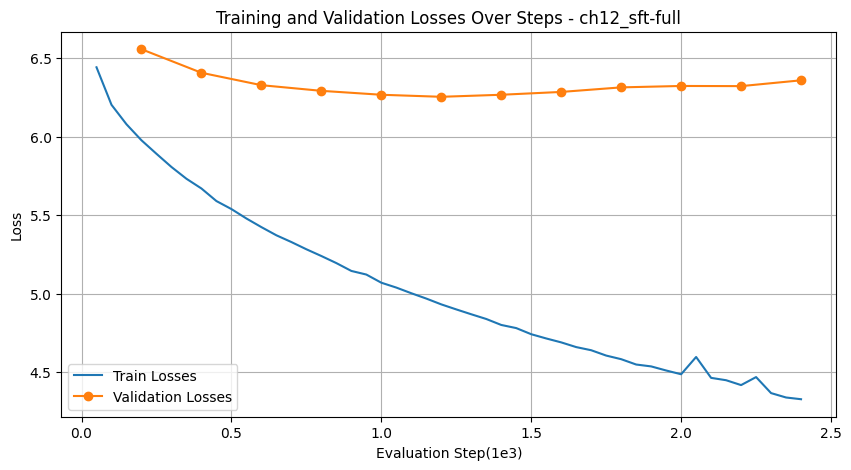

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

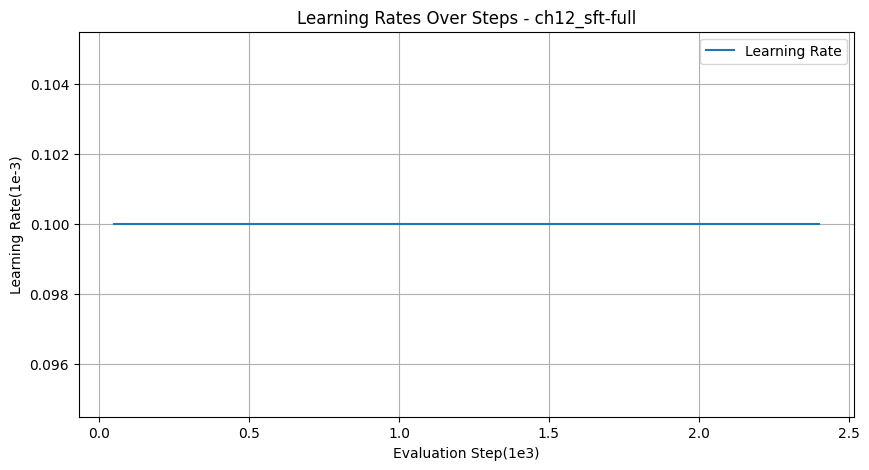

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")